# HRF Feature Analysis

### Imports

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway

### Load Data

In [13]:
features_dir = Path("../tests/features")
csv_files = sorted(features_dir.glob("features_*.csv"))

# exclude brain
csv_files = [f for f in csv_files if "brain" not in f.name.lower()]

data_list = []
for csv_file in csv_files:
    identifier = csv_file.stem.replace("features_", "")
    df_temp = pd.read_csv(csv_file)
    df_temp["identifier"] = identifier
    data_list.append(df_temp)

df_raw = pd.concat(data_list, ignore_index=True)

# samples become rows & features columns
df = df_raw.pivot_table(
    index="identifier",
    columns="feature",
    values="value",
    aggfunc="first",
)

phenotype_map = {"h": "healthy", "dr": "diabetes", "g": "glaucoma"}
sample_meta = pd.DataFrame(index=df.index)
sample_meta["sample_suffix"] = sample_meta.index.to_series().astype(str).str.split("_").str[-1]
sample_meta["phenotype"] = sample_meta["sample_suffix"].map(phenotype_map).fillna("unknown")

print(f"\nLoaded data: {df.shape[0]} samples x {df.shape[1]} features")
print(sample_meta["phenotype"].value_counts().sort_index().to_string())


Loaded data: 45 samples x 16 features
phenotype
diabetes    15
glaucoma    15
healthy     15


### Inspect it

In [14]:
df.head()

feature,fractal_dimension,fractal_dimension_r2,max_degree,max_length,mean_degree,mean_length,mean_tortuosity,min_length,num_bifurcations,num_components,num_edges,num_endpoints,num_nodes,std_length,std_tortuosity,total_length
identifier,,,,,,,,,,,,,,,,
01_dr,1.185432,0.985335,4.0,913.837662,2.264045,138.338131,1.090625,1.0,224.0,3.0,403.0,132.0,356.0,151.090956,0.099697,55750.266704
01_g,1.247439,0.980972,3.0,576.132034,2.283077,104.666376,1.083327,1.0,417.0,1.0,742.0,233.0,650.0,100.632692,0.053303,77662.450891
01_h,1.267857,0.978182,4.0,556.269119,2.125000,113.849903,1.086191,1.0,404.0,14.0,765.0,316.0,720.0,94.574224,0.050180,87095.176065
02_dr,1.227706,0.982158,4.0,789.901587,2.172414,126.478725,1.089795,1.0,304.0,6.0,567.0,218.0,522.0,122.204472,0.093913,71713.437113
02_g,1.263642,0.979602,4.0,569.274170,2.232323,96.139461,1.087649,1.0,487.0,7.0,884.0,305.0,792.0,88.284600,0.094029,84987.283354


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 01_dr to 15_h
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fractal_dimension     45 non-null     float64
 1   fractal_dimension_r2  45 non-null     float64
 2   max_degree            45 non-null     float64
 3   max_length            45 non-null     float64
 4   mean_degree           45 non-null     float64
 5   mean_length           45 non-null     float64
 6   mean_tortuosity       45 non-null     float64
 7   min_length            45 non-null     float64
 8   num_bifurcations      45 non-null     float64
 9   num_components        45 non-null     float64
 10  num_edges             45 non-null     float64
 11  num_endpoints         45 non-null     float64
 12  num_nodes             45 non-null     float64
 13  std_length            45 non-null     float64
 14  std_tortuosity        45 non-null     float64
 15  total_length          45 non-null  

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
feature,,,,,,,,
fractal_dimension,45.0,1.246580,0.024291,1.185432,1.231390,1.247865,1.263642,1.301986
fractal_dimension_r2,45.0,0.980919,0.001669,0.978182,0.979602,0.980807,0.981895,0.985335
max_degree,45.0,3.644444,0.484090,3.000000,3.000000,4.000000,4.000000,4.000000
max_length,45.0,704.985092,127.924609,526.102597,605.925974,702.790981,787.989899,1155.815367
mean_degree,45.0,2.210011,0.067364,2.098485,2.159363,2.200000,2.264348,2.378563
mean_length,45.0,109.767665,14.617432,85.174144,96.911030,110.151892,119.444941,138.338131
mean_tortuosity,45.0,1.090889,0.011001,1.080418,1.084256,1.088127,1.093313,1.132141
min_length,45.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
num_bifurcations,45.0,401.044444,101.201409,224.000000,334.000000,376.000000,459.000000,643.000000


### Phenotype summary

In [17]:
summary = df.join(sample_meta["phenotype"]).groupby("phenotype").agg(["mean", "std", "count"])
summary.columns = ["_".join(col) for col in summary.columns]
summary.reset_index(inplace=True)
summary

,phenotype,fractal_dimension_mean,fractal_dimension_std,fractal_dimension_count,fractal_dimension_r2_mean,fractal_dimension_r2_std,fractal_dimension_r2_count,max_degree_mean,max_degree_std,max_degree_count,...,num_nodes_count,std_length_mean,std_length_std,std_length_count,std_tortuosity_mean,std_tortuosity_std,std_tortuosity_count,total_length_mean,total_length_std,total_length_count
0,diabetes,1.241961,0.032776,15,0.982089,0.001739,15,4.000000,0.000000,15,...,15,113.614795,17.965941,15,0.141398,0.092602,15,76574.408486,12227.881429,15
1,glaucoma,1.253177,0.019861,15,0.980598,0.001493,15,3.800000,0.414039,15,...,15,93.622104,13.100503,15,0.077465,0.029130,15,80678.420662,7904.100446,15
2,healthy,1.244601,0.017664,15,0.980069,0.001074,15,3.133333,0.351866,15,...,15,105.448150,9.825844,15,0.073797,0.035724,15,76960.959625,7015.443469,15


### Feature distributions

/tmp/ipykernel_1025738/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_1025738/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_1025738/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_1025738/1446931430.py:10: FutureWarning: 

Passing `palette` without a

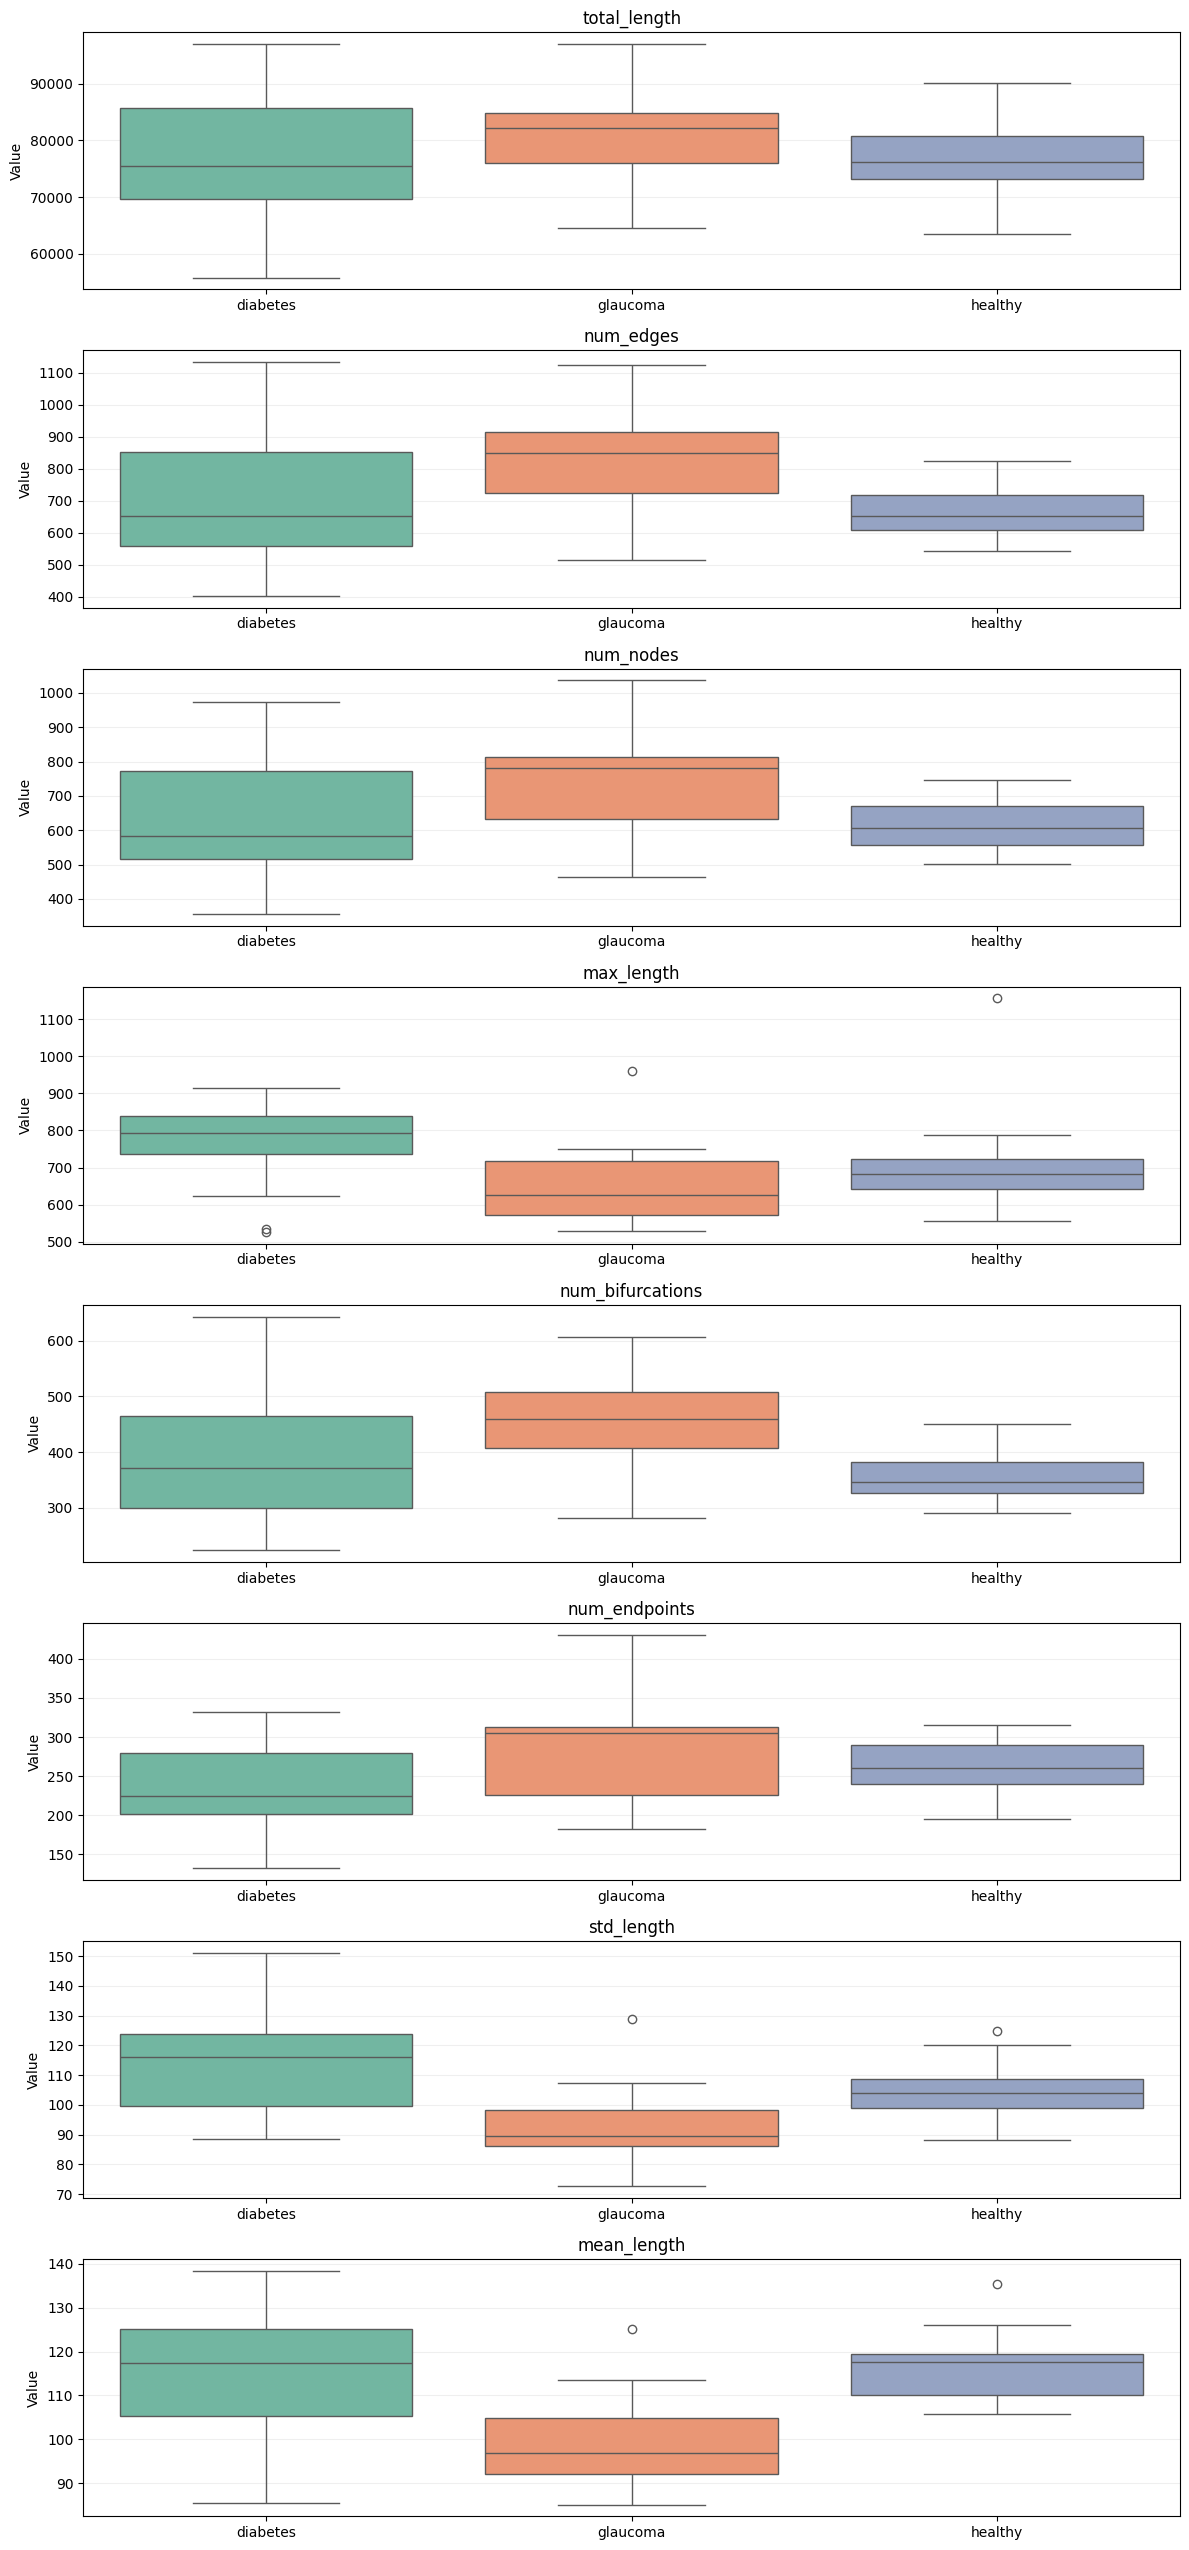

In [18]:
analysis_df = df.join(sample_meta["phenotype"])
variance_order = df.var().sort_values(ascending=False)
plot_features = variance_order.head(min(8, len(variance_order))).index.tolist()

fig, axes = plt.subplots(len(plot_features), 1, figsize=(12, 3.2 * len(plot_features)))
if len(plot_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, plot_features):
    sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("./figures/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Correlation

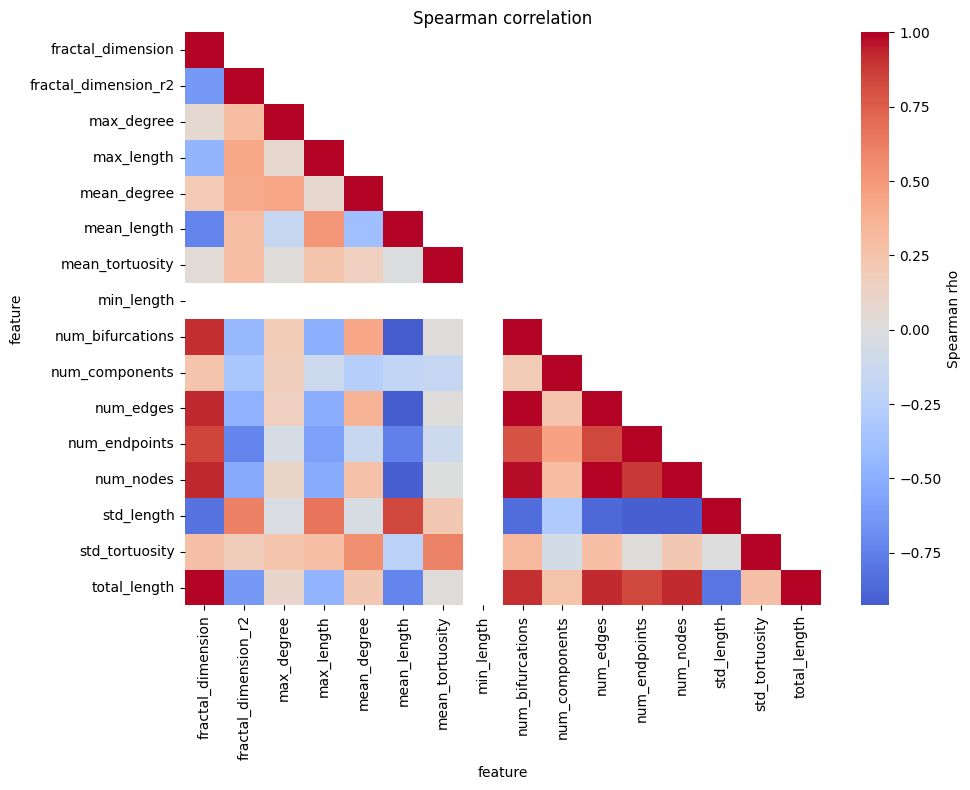

In [19]:
corr_spearman = df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)
sns.heatmap(
    corr_spearman,
    annot=False,
    mask=mask,
    cmap="coolwarm",
    center=0,
    ax=ax,
    cbar_kws={"label": "Spearman rho"},
)
ax.set_title("Spearman correlation")

plt.tight_layout()
plt.savefig("./figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
print("strongly correlated (abs(rho) > 0.8)")
upper = corr_spearman.where(np.triu(np.ones(corr_spearman.shape, dtype=bool), k=1))
upper.stack().rename("Spearman rho").rename_axis(["Feature 1", "Feature 2"]).loc[lambda s: s.abs() > 0.8].sort_values(key=np.abs, ascending=False).reset_index()

strongly correlated (abs(rho) > 0.8)


,Feature 1,Feature 2,Spearman rho
0,num_bifurcations,num_edges,0.995091
1,fractal_dimension,total_length,0.990382
2,num_edges,num_nodes,0.988635
3,num_bifurcations,num_nodes,0.973220
4,fractal_dimension,num_nodes,0.928458
5,mean_length,num_bifurcations,-0.927040
6,fractal_dimension,num_edges,0.925449
7,num_edges,total_length,0.922484
8,num_nodes,total_length,0.921344
9,mean_length,num_edges,-0.920441


### ANOVA Feature Difference

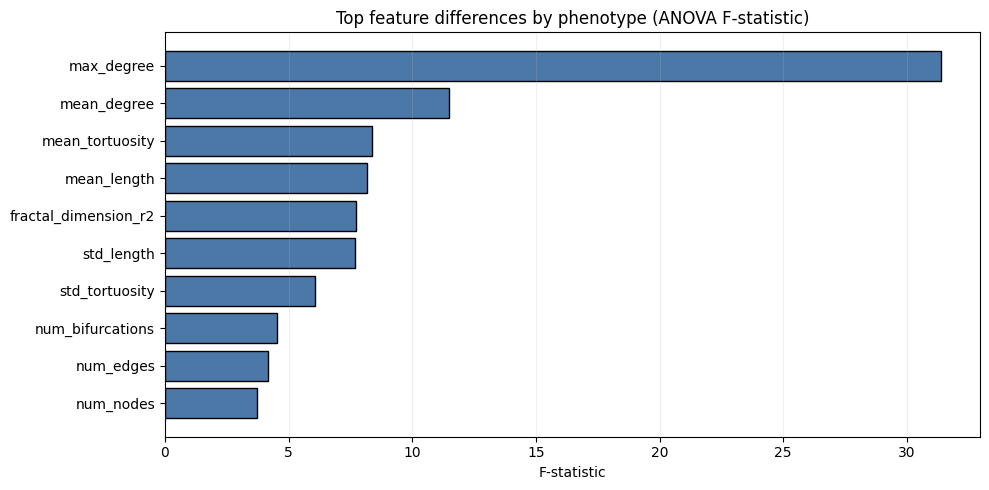

In [21]:
grouped = [group for _, group in analysis_df.groupby("phenotype")]

anova_rows = []
for feature in df.columns:
    feature_values = [group[feature].dropna() for group in grouped]
    f_stat, p_value = f_oneway(*feature_values)
    anova_rows.append({"Feature": feature, "F": f_stat, "p_value": p_value})

anova_df = pd.DataFrame(anova_rows).sort_values(["p_value", "F"], ascending=[True, False])

top_anova = anova_df.head(10).sort_values("F")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_anova["Feature"], top_anova["F"], color="#4c78a8", edgecolor="black")
ax.set_title("Top feature differences by phenotype (ANOVA F-statistic)")
ax.set_xlabel("F-statistic")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("./figures/feature_difference_anova.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
anova_df.head(10)

,Feature,F,p_value
2,max_degree,31.387097,4.601445e-09
4,mean_degree,11.472323,1.058826e-04
6,mean_tortuosity,8.375329,8.688956e-04
5,mean_length,8.152686,1.019425e-03
1,fractal_dimension_r2,7.706907,1.408935e-03
13,std_length,7.694329,1.421961e-03
14,std_tortuosity,6.077721,4.805635e-03
8,num_bifurcations,4.532294,1.650892e-02
10,num_edges,4.158260,2.250673e-02
12,num_nodes,3.733533,3.218073e-02
